# `solve_ivp` Simulation With Amplitude and Frequency Sweep

We solve the same internal-resonance model, but now using `scipy.integrate.solve_ivp`.

## Governing Equations (Expanded Form)

The two coupled second-order equations are

$$
\ddot{u}_1 + 2\varepsilon\mu_1\dot{u}_1 + \omega_1^2 u_1 = k_1 u_1 u_2 + \varepsilon f_1\cos(\Omega t),
$$

$$
\ddot{u}_2 + 2\varepsilon\mu_2\dot{u}_2 + \omega_2^2 u_2 = k_2 u_1^2 + \varepsilon^2 f_2\cos(\Omega t).
$$

For each sweep point, we vary both:
- excitation amplitude $f_2$
- excitation frequency ratio $r = \Omega/\omega_2$ (so $\Omega = r\,\omega_2$).

To integrate with `solve_ivp`, we use the first-order state

$$
\mathbf{y} = [u_1,\; v_1,\; u_2,\; v_2]^T,
\qquad v_1 = \dot{u}_1,\; v_2 = \dot{u}_2,
$$

with

$$
\dot{u}_1 = v_1,
$$

$$
\dot{v}_1 = -\omega_1^2 u_1 - 2\varepsilon\mu_1 v_1 + k_1 u_1 u_2 + \varepsilon f_1\cos(\Omega t),
$$

$$
\dot{u}_2 = v_2,
$$

$$
\dot{v}_2 = -\omega_2^2 u_2 - 2\varepsilon\mu_2 v_2 + k_2 u_1^2 + \varepsilon^2 f_2\cos(\Omega t).
$$

Steady-state RMS amplitudes are computed after transient removal:

$$
A_i(f_2, \Omega) = \sqrt{\frac{1}{T_s}\int_{t_{\mathrm{trans}}}^{t_{\mathrm{end}}} u_i^2(t) \, dt},\qquad i=1,2.
$$

In [90]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
import importlib

# add project root to Python path (highest priority)
project_root = Path.cwd().parents[2]
project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

import Modeling
import Modeling.models.single_piezo as single_piezo
importlib.reload(single_piezo)
PiezoBeamFRF = single_piezo.PiezoBeamFRF
beam = PiezoBeamFRF(conf='series')  # or 'parallel
print('Electromechanical coupling coefficient : ', beam.theta_r)

Electromechanical coupling coefficient :  [ 0.03916596 -0.13602836  0.22331952 -0.31286861]


In [91]:
import time
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

try:
    from joblib import Parallel, delayed
    HAS_JOBLIB = True
except ImportError:
    HAS_JOBLIB = False

# -----------------------------
# Parameters (same physical model)
# -----------------------------
eps = 1
sigma2 = 0.0
freq_scale = 54 * 2 * pi
w1 = freq_scale
w2 = 2 * w1 - eps * sigma2
mu1, mu2 =  0.33929200658769765,  3.392920065876977
k1, k2 = 4.6e+07,  4.6e+07
f1 = 0.0

f2_values = np.linspace(0.1, 0.5, 30) 
print("k1 = ", f'{k1:0.1e}')
print("k2 = ", f'{k2:0.1e}')
print("f2 values: ", f2_values)
print('mu1 = ', mu1)
print('mu2 = ', mu2)
w1_bar = w1 / w2
w2_bar = 1.0
sigma2_bar = sigma2

# damping
mu1_bar = mu1 / w1
mu2_bar = mu2 / w1

# displacement scale (depends on f2)
u0_values = f2_values / (w1**2)

# nonlinear coefficients
k1_bar_values = k1 * f2_values / (w1**4)
k2_bar_values = k2 * f2_values / (w1**4)

# forcing
f2_bar_values = np.ones_like(f2_values)
f1_bar = f1 / f2_values

# ================= PRINT =================
print("\n=== NONDIMENSIONAL PARAMETERS ===")
print(f"eps = {eps}")
print(f"sigma2_bar = {sigma2_bar}")
print(f"w1_bar = {w1_bar}")
print(f"mu1_bar = {mu1_bar}, mu2_bar = {mu2_bar}")
print(f"k1_bar (first 3) = {k1_bar_values[:3]}")
print(f"k2_bar (first 3) = {k2_bar_values[:3]}")
print(f"f2_bar = {f2_bar_values[0]} (constant)")


k1 =  4.6e+07
k2 =  4.6e+07
f2 values:  [0.1        0.1137931  0.12758621 0.14137931 0.15517241 0.16896552
 0.18275862 0.19655172 0.21034483 0.22413793 0.23793103 0.25172414
 0.26551724 0.27931034 0.29310345 0.30689655 0.32068966 0.33448276
 0.34827586 0.36206897 0.37586207 0.38965517 0.40344828 0.41724138
 0.43103448 0.44482759 0.45862069 0.47241379 0.4862069  0.5       ]
mu1 =  0.33929200658769765
mu2 =  3.392920065876977

=== NONDIMENSIONAL PARAMETERS ===
eps = 1
sigma2_bar = 0.0
w1_bar = 0.5
mu1_bar = 0.001, mu2_bar = 0.010000000000000002
k1_bar (first 3) = [0.00034711 0.00039498 0.00044286]
k2_bar (first 3) = [0.00034711 0.00039498 0.00044286]
f2_bar = 1.0 (constant)


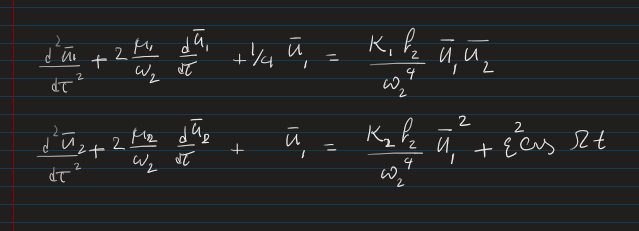

In [92]:

freq_ratio_values = np.linspace(0.98, 1.02, 10)
samples_per_period = 30
n_periods_total = 90
n_periods_transient = 60

omega_exc_values = freq_ratio_values * w2

rtol = 1e-7
atol = 1e-9

def rhs(t, y, f2, omega_exc):
    u1, v1, u2, v2 = y
    F1 = eps * f1 * np.cos(omega_exc * t)
    F2 = (eps**2) * f2 * np.cos(omega_exc * t)

    du1 = v1
    dv1 = -w1**2 * u1 - 2 * eps * mu1 * v1 + k1 * u1 * u2 
    du2 = v2
    dv2 = -w2**2 * u2 - 2 * eps * mu2 * v2 + k2 * u1**2 + F2

    return np.array([du1, dv1, du2, dv2])

def run_case_ivp(f2, omega_exc, y0=None):
    dt = 2 * pi / (samples_per_period * omega_exc)
    t_end = n_periods_total * 2 * pi / omega_exc
    t_trans = n_periods_transient * 2 * pi / omega_exc

    n_steps = int(np.round(t_end / dt))
    t_eval = np.linspace(0.0, n_steps * dt, n_steps + 1)

    if y0 is None:
        y0 = np.array([0.0, 1e-3, 0.0, 0.0])

    t0 = time.perf_counter()
    sol = solve_ivp(
        rhs,
        [0.0, t_eval[-1]],
        y0,
        args=(f2, omega_exc),
        t_eval=t_eval,
        method="RK45",
        rtol=rtol,
        atol=atol,
    )
    runtime = time.perf_counter() - t0

    mask = sol.t >= t_trans
    u1 = sol.y[0]
    u2 = sol.y[2]

    a1_rms = np.sqrt(np.mean(u1[mask] ** 2))
    a2_rms = np.sqrt(np.mean(u2[mask] ** 2))

    return {
        "t": sol.t,
        "y": sol.y,
        "a1_rms": a1_rms,
        "a2_rms": a2_rms,
        "runtime_s": runtime,
    }

def run_frequency_row(i, omega_exc):
    # Keep continuation along f2 inside each worker.
    y0_row = np.array([0.0, 1e-4, 0.0, 0.0])
    row_a1 = np.zeros(len(f2_values))
    row_a2 = np.zeros(len(f2_values))
    row_runtime = np.zeros(len(f2_values))

    for j, f2 in enumerate(f2_values):
        out = run_case_ivp(f2, omega_exc, y0=y0_row)
        row_a1[j] = out["a1_rms"]
        row_a2[j] = out["a2_rms"]
        row_runtime[j] = out["runtime_s"]
        y0_row = out["y"][:, -1].copy()

    return i, row_a1, row_a2, row_runtime

A1 = np.zeros((len(freq_ratio_values), len(f2_values)))
A2 = np.zeros((len(freq_ratio_values), len(f2_values)))
RUNTIME = np.zeros((len(freq_ratio_values), len(f2_values)))

n_jobs = -1  # use all cores
t_sweep_start = time.perf_counter()
if HAS_JOBLIB:
    results = Parallel(n_jobs=n_jobs, backend="loky", verbose=12)(
        delayed(run_frequency_row)(i, omega_exc)
        for i, omega_exc in enumerate(omega_exc_values)
    )
else:
    print("joblib not found, running sequential sweep.")
    results = [
        run_frequency_row(i, omega_exc)
        for i, omega_exc in enumerate(omega_exc_values)
    ]
t_sweep_total = time.perf_counter() - t_sweep_start

for i, row_a1, row_a2, row_runtime in results:
    A1[i, :] = row_a1
    A2[i, :] = row_a2
    RUNTIME[i, :] = row_runtime

print("Sweep completed (parallel over frequency rows when joblib is available).")
print(f"Grid size: {A1.shape[0]} frequency points x {A1.shape[1]} amplitude points")
print(f"Average runtime per case: {np.mean(RUNTIME):.3f} s")
print(f"Total wall time: {t_sweep_total:.3f} s")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   19.5s
[Parallel(n_jobs=-1)]: Done   2 out of  10 | elapsed:   19.7s remaining:  1.3min
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:   19.9s remaining:   46.6s
[Parallel(n_jobs=-1)]: Done   4 out of  10 | elapsed:   20.1s remaining:   30.2s
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:   20.3s remaining:   20.3s
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:   20.5s remaining:   13.6s
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:   20.5s remaining:    8.7s
[Parallel(n_jobs=-1)]: Done   8 out of  10 | elapsed:   20.5s remaining:    5.1s


Sweep completed (parallel over frequency rows when joblib is available).
Grid size: 10 frequency points x 30 amplitude points
Average runtime per case: 0.677 s
Total wall time: 20.836 s


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   20.7s finished


In [93]:
# fig, axs = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

# extent = [f2_values[0], f2_values[-1], freq_ratio_values[0], freq_ratio_values[-1]]

# im0 = axs[0].imshow(A1, origin="lower", aspect="auto", extent=extent)
# axs[0].set_title(r"$A_1$ RMS (solve_ivp)")
# axs[0].set_xlabel(r"forcing amplitude $f_2$")
# axs[0].set_ylabel(r"frequency ratio $\Omega/\omega_2$")
# fig.colorbar(im0, ax=axs[0], label="RMS")

# im1 = axs[1].imshow(A2, origin="lower", aspect="auto", extent=extent)
# axs[1].set_title(r"$A_2$ RMS (solve_ivp)")
# axs[1].set_xlabel(r"forcing amplitude $f_2$")
# axs[1].set_ylabel(r"frequency ratio $\Omega/\omega_2$")
# fig.colorbar(im1, ax=axs[1], label="RMS")

# im2 = axs[2].imshow(RUNTIME, origin="lower", aspect="auto", extent=extent)
# axs[2].set_title("Runtime per case [s] (solve_ivp)")
# axs[2].set_xlabel(r"forcing amplitude $f_2$")
# axs[2].set_ylabel(r"frequency ratio $\Omega/\omega_2$")
# fig.colorbar(im2, ax=axs[2], label="s")

# plt.show()


In [94]:
A2.shape
A2

array([[3.95802807e-06, 4.31367402e-06, 4.82988443e-06, 5.34964895e-06,
        5.86912030e-06, 6.38856864e-06, 6.90800857e-06, 7.42745154e-06,
        7.94690079e-06, 8.46634885e-06, 8.98580231e-06, 9.50524694e-06,
        1.00246950e-05, 1.05441516e-05, 1.10636039e-05, 1.15830497e-05,
        1.21025097e-05, 1.26219637e-05, 1.31414148e-05, 1.36608715e-05,
        1.41803249e-05, 1.46997803e-05, 1.52192339e-05, 1.57386915e-05,
        1.62581410e-05, 1.67775867e-05, 1.72970428e-05, 1.78165017e-05,
        1.83359558e-05, 1.88554150e-05],
       [4.56301691e-06, 5.38467282e-06, 6.02366023e-06, 6.67854525e-06,
        7.33250623e-06, 7.98646500e-06, 8.64046737e-06, 9.29445318e-06,
        9.94843161e-06, 1.06024267e-05, 1.12564200e-05, 1.19104113e-05,
        1.25644076e-05, 1.32184043e-05, 1.38724007e-05, 1.45263965e-05,
        1.51803905e-05, 1.58343891e-05, 1.64883905e-05, 1.71423791e-05,
        1.77963557e-05, 1.84503742e-05, 1.91043707e-05, 1.97583697e-05,
        2.04123693e-05,

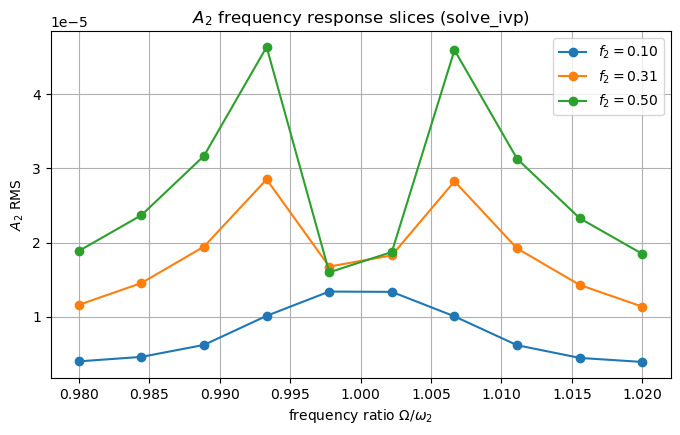

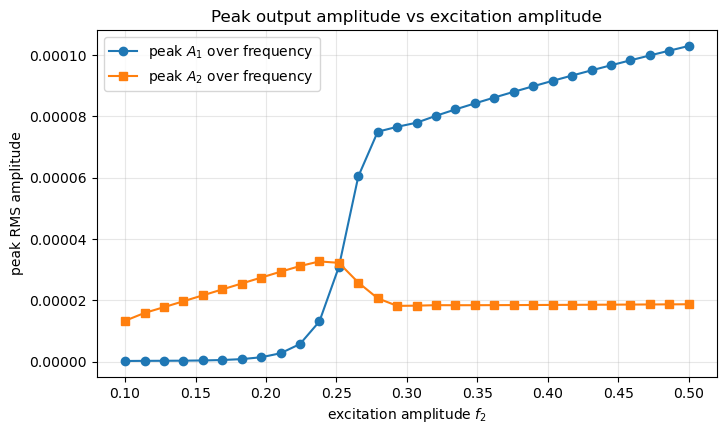

In [95]:

pick_js = [0, len(f2_values) // 2, len(f2_values) - 1]
plt.figure(figsize=(8, 4.5))
for j in pick_js:
    plt.plot(freq_ratio_values, A2[:, j], marker="o", label=fr"$f_2={f2_values[j]:.2f}$")
plt.xlabel(r"frequency ratio $\Omega/\omega_2$")
plt.ylabel(r"$A_2$ RMS")
plt.title(r"$A_2$ frequency response slices (solve_ivp)")
plt.grid(True)
plt.legend()
plt.show()

target_ratios = [0.98, 1.00, 1.02]
idxs = [int(np.argmin(np.abs(freq_ratio_values - r))) for r in target_ratios]
idx = idxs[1]
 # index for ratio closest to 1.00
plt.figure(figsize=(8, 4.5))
plt.plot(f2_values, A1[idx, :], "-o", label=r"peak $A_1$ over frequency")
plt.plot(f2_values, A2[idx, :], "-s", label=r"peak $A_2$ over frequency")
plt.xlabel(r"excitation amplitude $f_2$")
plt.ylabel("peak RMS amplitude")
plt.title("Peak output amplitude vs excitation amplitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()